In [1]:
pip install Faker

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   --------------- ------------------------ 0.8/2.0 MB 753.4 kB/s eta 0:00:02
   --------------- ------------------------ 0.8/2.0 MB 753.4 kB/s eta 0:00:02
   --------------- ------------------------ 0.8/2.0 MB 753.4 kB/s eta 0:00:02
   -------------------- ------------------- 1.0/2.0 MB 663.5 kB/s eta 0:00:02
   -------------------- ------------------- 1.0/2.0 MB 663.5 kB/s eta 0:00:02
   -------------------------- ------------- 1.3/2.0 MB 656

In [2]:
from faker import Faker

In [3]:
import pandas as pd

In [4]:
import random

In [5]:
#Creamos una instancia de Faker
fake = Faker("es_MX")

In [6]:
#Generamos datos sinteticos: 100 registros
datos = []
for i in range(100):
    datos.append({
        "id_usuario": i +1,
        "nombre": fake.name(),
        "correo": fake.email(),
        "edad": random.randint(100,50000),
        "plataforma": random.choice(
            ["Tiktok", "Instagram","Youtube"]
        )
    })

In [7]:
df = pd.DataFrame(datos)
df.head()

,id_usuario,nombre,correo,edad,plataforma
0,1,Ángela Ana María Gamboa Figueroa,carlotafarias@example.org,45407,Youtube
1,2,Esther Inés Matías,noemi94@example.net,1347,Instagram
2,3,Lucas Luis Miguel Alonzo,karinaesquivel@example.net,39985,Youtube
3,4,Jacobo Camarillo Ledesma,irizarryraquel@example.com,7098,Tiktok
4,5,Adriana Rosalia Rodríquez,german11@example.com,1934,Tiktok


In [8]:
#Exploracion del DataSet
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  100 non-null    int64 
 1   nombre      100 non-null    object
 2   correo      100 non-null    object
 3   edad        100 non-null    int64 
 4   plataforma  100 non-null    object
dtypes: int64(2), object(3)
memory usage: 4.0+ KB


In [9]:
#Estadistica descriptiva
df.describe(include="all")

,id_usuario,nombre,correo,edad,plataforma
count,100.000000,100,100,100.000000,100
unique,NaN,100,100,NaN,3
top,NaN,Ángela Ana María Gamboa Figueroa,carlotafarias@example.org,NaN,Tiktok
freq,NaN,1,1,NaN,40
mean,50.500000,NaN,NaN,27003.200000,NaN
std,29.011492,NaN,NaN,15022.689146,NaN
min,1.000000,NaN,NaN,1347.000000,NaN
25%,25.750000,NaN,NaN,14790.250000,NaN
50%,50.500000,NaN,NaN,29557.500000,NaN
75%,75.250000,NaN,NaN,39994.500000,NaN


In [10]:
#Importar librerias para graficar
import seaborn as sns
import matplotlib.pyplot as plt

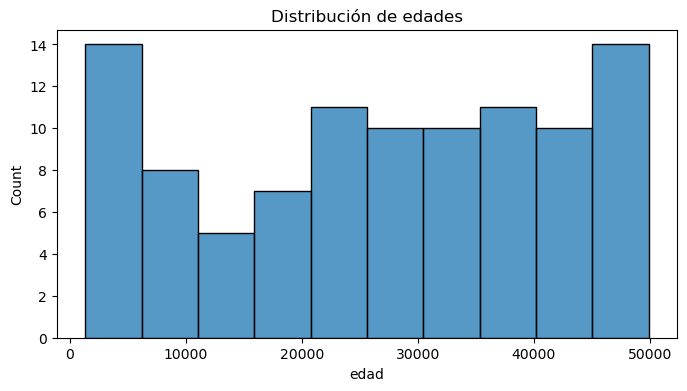

In [11]:
#Distribución de edades
plt.figure(figsize=(8,4))
sns.histplot(
    df["edad"],
    bins=10
)
plt.title("Distribución de edades")
plt.show()

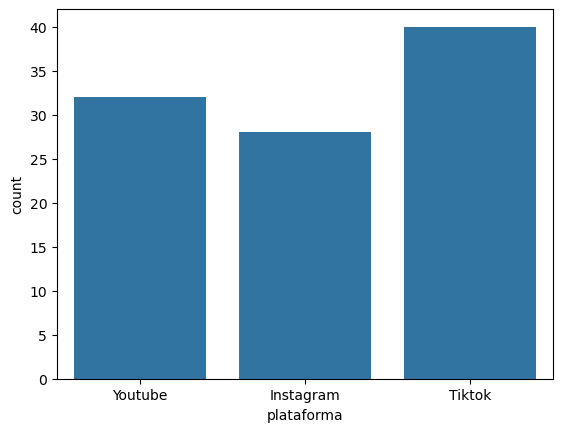

In [12]:
#Usuarios por plataforma
sns.countplot(
    x="plataforma",
    data=df
)
plt.show()

In [13]:
#Generamos una copia para contaminarla
df_sucio = df.copy()

In [14]:
#Le colocamos valores nulos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"nombre"] = None

In [15]:
df_sucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  100 non-null    int64 
 1   nombre      95 non-null     object
 2   correo      100 non-null    object
 3   edad        100 non-null    int64 
 4   plataforma  100 non-null    object
dtypes: int64(2), object(3)
memory usage: 4.0+ KB


In [16]:
#edades invalidas
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"edad"] = -10

In [17]:
df_sucio.describe()["edad"]

count      100.00000
mean     25679.87000
std      15859.60689
min        -10.00000
25%       9959.25000
50%      28720.00000
75%      38697.00000
max      49913.00000
Name: edad, dtype: float64

In [18]:
#seguidores imposibles
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"seguidores"] = 5000000

In [19]:
df_sucio.describe()["seguidores"]

count          5.0
mean     5000000.0
std            0.0
min      5000000.0
25%      5000000.0
50%      5000000.0
75%      5000000.0
max      5000000.0
Name: seguidores, dtype: float64

In [20]:
#Generamos correos invalidos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"correo"] = "correo_invalido"

In [22]:
df_sucio.describe(include=["object"])

,nombre,correo,plataforma
count,95,100,100
unique,95,96,3
top,Ángela Ana María Gamboa Figueroa,correo_invalido,Tiktok
freq,1,5,40


In [23]:
df_sucio.isnull().sum()

id_usuario     0
nombre         5
correo         0
edad           0
plataforma     0
seguidores    95
dtype: int64

In [25]:
pd.set_option('display.float_format',lambda x: '%.2f' % x)

In [26]:
#estadisticas
df_sucio.describe(include="all")

,id_usuario,nombre,correo,edad,plataforma,seguidores
count,100.00,95,100,100.00,100,5.00
unique,NaN,95,96,NaN,3,NaN
top,NaN,Ángela Ana María Gamboa Figueroa,correo_invalido,NaN,Tiktok,NaN
freq,NaN,1,5,NaN,40,NaN
mean,50.50,NaN,NaN,25679.87,NaN,5000000.00
std,29.01,NaN,NaN,15859.61,NaN,0.00
min,1.00,NaN,NaN,-10.00,NaN,5000000.00
25%,25.75,NaN,NaN,9959.25,NaN,5000000.00
50%,50.50,NaN,NaN,28720.00,NaN,5000000.00
75%,75.25,NaN,NaN,38697.00,NaN,5000000.00
